In [11]:
# 🏠 PROJECT 2: HOUSE PRICE PREDICTION (REGRESSION)

In [15]:
# SECTION 1: PROBLEM UNDERSTANDING + SETUP


In [17]:
# Step 1: Understand the Problem
'''
Problem:
    Predict house prices based on features like area, bedrooms, location, etc.

Type of Problem
Target: Price
Continuous values (not 0/1)

 This is:
 Regression Problem

'''

'\nProblem:\n    Predict house prices based on features like area, bedrooms, location, etc.\n\nType of Problem\nTarget: Price\nContinuous values (not 0/1)\n\n This is:\n Regression Problem\n\n'

In [19]:
# Step 2: Define X and y
'''
X (features) → Area, Bedrooms, Bathrooms, etc.
y (target) → Price
'''

'\nX (features) → Area, Bedrooms, Bathrooms, etc.\ny (target) → Price\n'

In [21]:
# Step 3: Dataset Selection
'''
“House Prices - Advanced Regression Techniques” 
Dataset on Kaggle.

This is:

Industry-famous dataset
Used for regression tasks
Slightly more complex than Titanic
'''

'\n“House Prices - Advanced Regression Techniques” \nDataset on Kaggle.\n\nThis is:\n\nIndustry-famous dataset\nUsed for regression tasks\nSlightly more complex than Titanic\n'

In [13]:
# Step 5: Load Dataset
import pandas as pd

df = pd.read_csv("train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [23]:
df.shape

(1460, 81)

In [25]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [29]:
# Insights
'''
Target → SalePrice
Numerical → LotArea, GrLivArea, GarageArea
Categorical → MSZoning, Neighborhood, HouseStyle etc.

The dataset is significantly more complex than Titanic, containing a large number of features (~80), including both numerical and categorical variables.
It also contains substantial missing values across multiple columns, indicating the need for careful data cleaning and feature engineering.

'''

'\nTarget → SalePrice\nNumerical → LotArea, GrLivArea, GarageArea\nCategorical → MSZoning, Neighborhood, HouseStyle etc.\n\nThe dataset is significantly more complex than Titanic, containing a large number of features (~80), including both numerical and categorical variables.\nIt also contains substantial missing values across multiple columns, indicating the need for careful data cleaning and feature engineering.\n\n'

In [31]:
# SECTION 2: ADVANCED EDA
'''
Goal:
-- Understand target variable deeply
-- Identify important features
-- Detect skewness & relationships
'''

'\nGoal:\n-- Understand target variable deeply\n-- Identify important features\n-- Detect skewness & relationships\n'

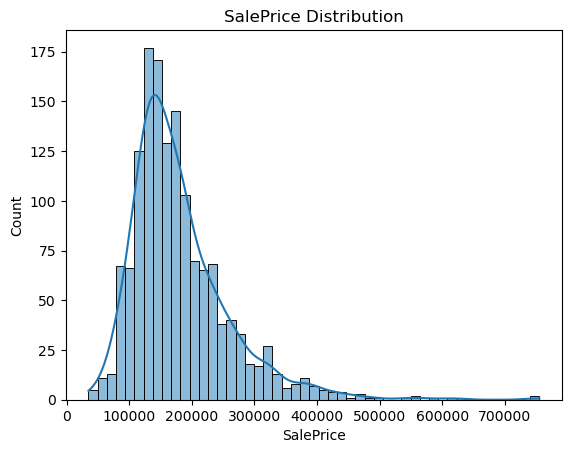

In [5]:
# Step 1: Analyze Target Variable (SalePrice)
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['SalePrice'], kde=True)
plt.title("SalePrice Distribution")
plt.show()

In [33]:
'''
 Important Concept

 Most real-world price data is:
 Right Skewed (positively skewed)

Meaning:
-- Few very expensive houses
-- Many average-priced houses
'''

'\n Important Concept\n\n Most real-world price data is:\n Right Skewed (positively skewed)\n\nMeaning:\n-- Few very expensive houses\n-- Many average-priced houses\n'

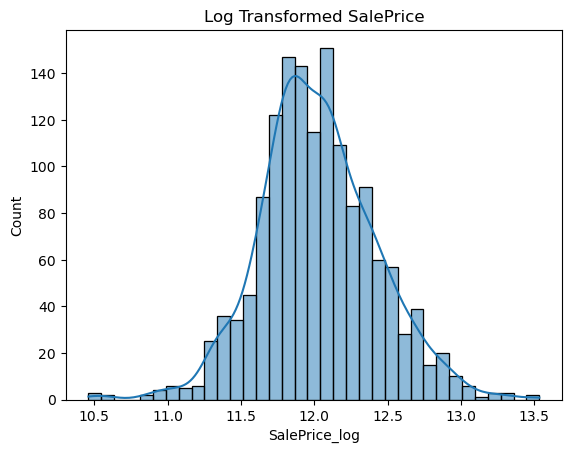

In [79]:

# Step 2: Apply Log Transformation
import numpy as np

df['SalePrice_log'] = np.log(df['SalePrice'])
sns.histplot(df['SalePrice_log'], kde = True)
plt.title("Log Transformed SalePrice")
plt.show()

In [37]:
'''
 Why do this?

 Models (Linear Regression) work better when:
    -- Data is normally distributed

 Log transform:
    -- Reduces skewness
    -- Improves model performance
'''

'\n Why do this?\n\n Models (Linear Regression) work better when:\n    -- Data is normally distributed\n\n Log transform:\n    -- Reduces skewness\n    -- Improves model performance\n'

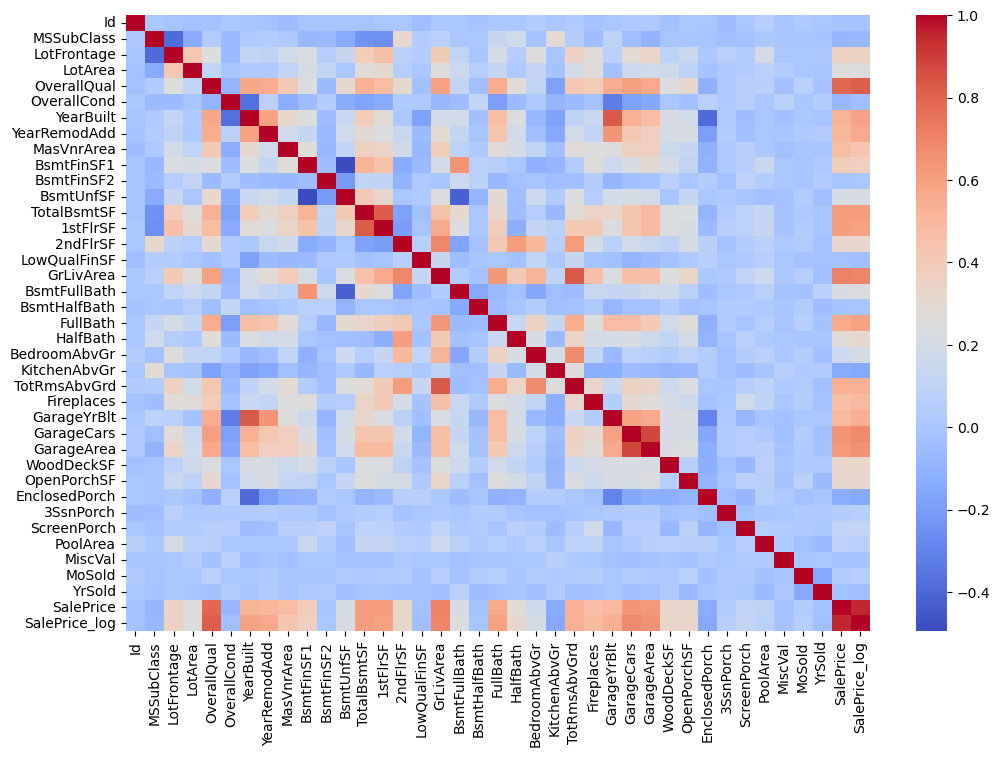

In [9]:
# Step 3: Correlation Analysis
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm')
plt.show()

In [39]:

# This code selects the top 10 features that have the highest correlation with the target variable SalePrice, helping identify important predictors.
corr['SalePrice'].sort_values(ascending=False).head(10)

SalePrice        1.000000
SalePrice_log    0.948374
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
Name: SalePrice, dtype: float64

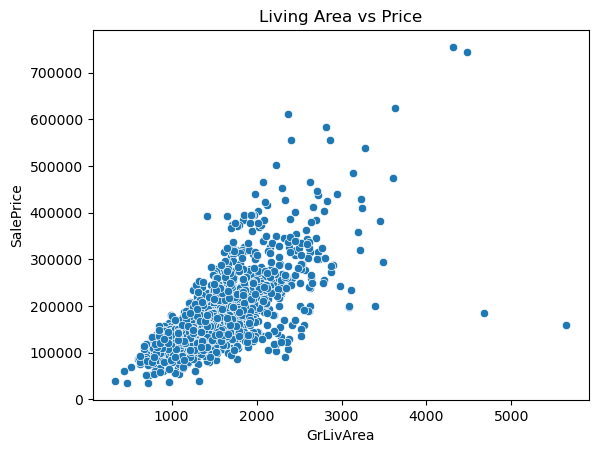

In [41]:
# Step 4: Analyze Important Features
# Example: GrLivArea

sns.scatterplot(x='GrLivArea', y='SalePrice', data=df)
plt.title("Living Area vs Price")
plt.show()

# Bigger house → higher price

In [43]:
# There is a strong positive linear relationship between living area (GrLivArea) and SalePrice, indicating that larger houses tend to have higher prices.


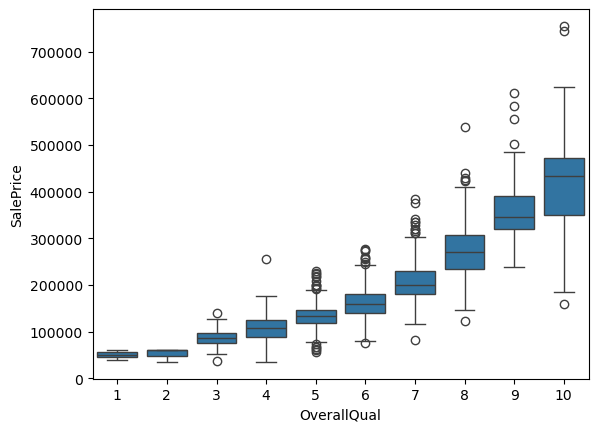

In [45]:
# OverallQual vs SalePrice
sns.boxplot(x = "OverallQual", y = "SalePrice", data = df)
plt.show()

# Better quality → higher price

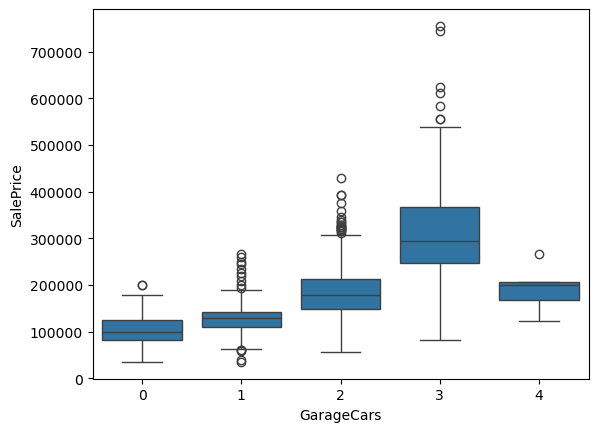

In [47]:
# GarageCars vs Price
sns.boxplot(x = "GarageCars", y = "SalePrice", data = df)
plt.show()

# More garage capacity → higher price

In [49]:

# Step 5: Missing Values Deep Analysis
df.isnull().sum().sort_values(ascending=False).head(10)

PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
MasVnrType      872
FireplaceQu     690
LotFrontage     259
GarageYrBlt      81
GarageCond       81
GarageType       81
dtype: int64

In [51]:
# SECTION 3: ADVANCED DATA CLEANING + FEATURE ENGINEERING
'''
 Goal:

-- Handle complex missing values
-- Deal with high-dimensional data
-- Convert everything into model-ready format
'''

'\n Goal:\n\n-- Handle complex missing values\n-- Deal with high-dimensional data\n-- Convert everything into model-ready format\n'

In [53]:
# Step 1: Understand Missing Values Properly
df.isnull().sum().sort_values(ascending = False).head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Id                 0
dtype: int64

In [55]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [57]:
'''
PoolQC → 1453 missing
MiscFeature → 1406
Alley → many missing
Fence → many missing

 Key Insight
 These are not “missing” — they mean:
-- No Pool
-- No Alley
-- No Fence
'''


'\nPoolQC → 1453 missing\nMiscFeature → 1406\nAlley → many missing\nFence → many missing\n\n Key Insight\n These are not “missing” — they mean:\n-- No Pool\n-- No Alley\n-- No Fence\n'

In [59]:

# Step 2: Fill Missing with Meaning (Industry Trick)
# -- Fill “None” for such features
cols_fill_none = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu']

for col in cols_fill_none:
    df[col] = df[col].fillna('None')

In [61]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,12,2008,WD,Normal,250000


In [63]:
# Step 3: Handle Numerical Missing Values
# LotFrontage
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())

# Median is preferred because LotFrontage may contain outliers, and median provides a robust central tendency measure.


In [65]:
# GarageYrBlt
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)


In [67]:
'''
 Why?
-- Median → robust
-- 0 → indicates “no garage”
'''


'\n Why?\n-- Median → robust\n-- 0 → indicates “no garage”\n'

In [69]:
# Step 4: Drop Useless Columns
df.drop(['Id'], axis=1, inplace=True)

In [71]:
'''
 Why?
-- Just identifier
-- No predictive value
'''

'\n Why?\n-- Just identifier\n-- No predictive value\n'

In [73]:
# Step 5: Handle Categorical Variables
# Convert using One-Hot Encoding
df = pd.get_dummies(df, drop_first=True)


In [75]:
'''
 Why?
-- Models need numbers
-- Handles all categorical variables at once 

 Important Result

 Columns increases massively (200+)
 Called High Dimensional Data
'''

'\n Why?\n-- Models need numbers\n-- Handles all categorical variables at once \n\n Important Result\n\n Columns increases massively (200+)\n Called High Dimensional Data\n'

In [81]:
# Step 6: Feature Scaling (VERY IMPORTANT for Regression)
# Linear regression is sensitive to feature scale, so scaling ensures all features contribute equally and improves model convergence.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = df.drop(['SalePrice', 'SalePrice_log'], axis = 1)
y = df['SalePrice_log']

X_scaled = scaler.fit_transform(X)

# Log transformation reduces skewness and stabilizes variance, making the data more suitable for linear regression assumptions.


In [83]:
# SECTION 4: LINEAR REGRESSION MODEL
'''
 Goal:

-- Train Linear Regression model
-- Evaluate using proper metrics (NOT accuracy)
-- Understand model performance deeply
'''

'\n Goal:\n\n-- Train Linear Regression model\n-- Evaluate using proper metrics (NOT accuracy)\n-- Understand model performance deeply\n'

In [85]:
# Step 1: Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size = 0.2,
    random_state = 42
)

In [87]:
# Step 2: Train Linear Regression Model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [89]:
# ValueError: Input X contains NaN.
'''
 Problem: Input X contains NaN

 Meaning:
-- Our dataset still has missing values
-- And LinearRegression cannot handle NaN
'''

'\n Problem: Input X contains NaN\n\n Meaning:\n-- Our dataset still has missing values\n-- And LinearRegression cannot handle NaN\n'

In [91]:
# Step-by-Step Fix (Industry Standard)
# Step 1: Check Remaining Missing Values
X.isnull().sum().sort_values(ascending=False).head(10)


MasVnrArea          8
MSSubClass          0
BsmtFinType1_GLQ    0
Foundation_Slab     0
Foundation_Stone    0
Foundation_Wood     0
BsmtQual_Fa         0
BsmtQual_Gd         0
BsmtQual_TA         0
BsmtCond_Gd         0
dtype: int64

In [93]:
# Step 2: Confirm Total Missing
X.isnull().sum().sum()

8

In [95]:
# Step 3: Quick Fix (Best for Now)
# Fill remaining missing values with 0
X = X.fillna(0)

In [99]:
'''Why this works?
After encoding, most missing values are:
-- Absence of category

0 becomes a safe default
'''

'Why this works?\nAfter encoding, most missing values are:\n-- Absence of category\n\n0 becomes a safe default\n'

In [103]:
X.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,False,False,False,False,True,False,False,False,True,False
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,False,False,False,False,True,False,False,False,True,False
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,False,False,False,False,True,False,False,False,True,False
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,False,False,False,False,True,False,False,False,False,False
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,False,False,False,False,True,False,False,False,True,False


In [105]:
# Step 4: Scale Again
X_scaled = scaler.fit_transform(X)

In [107]:
# Step 5: Train Again
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [109]:
'''
Why Linear Regression?

-- Baseline model 
-- Easy to interpret 
-- Industry starting point 
'''

'\nWhy Linear Regression?\n\n-- Baseline model \n-- Easy to interpret \n-- Industry starting point \n'

In [111]:

# Step 3: Predictions
y_pred = model.predict(X_test)

In [113]:
# Step 4: Evaluation Metrics
from sklearn.metrics import root_mean_squared_error, r2_score

rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE : ", rmse)
print("R2 Score : ", r2)

RMSE :  228379251.31676576
R2 Score :  -2.794925197365481e+17


In [115]:
# Step 5: Understand Metrics (CRITICAL)
'''
RMSE
-- Measures average prediction error
-- Lower = better 

Example:
RMSE = 0.17 (log scale)

R² Score
Range: 0 → 1
Closer to 1 = better ✔

Example:
0.83 → model explains 83% variance
'''

'''
IMPORTANT NOTE

We used log(SalePrice)

So:
-- RMSE is in log scale
-- Not directly interpretable in price

'''

'\nIMPORTANT NOTE\n\nWe used log(SalePrice)\n\nSo:\n-- RMSE is in log scale\n-- Not directly interpretable in price\n\n'

In [117]:

# Step 6: Convert Back (Advanced Insight)
y_pred_actual = np.exp(y_pred)
y_test_actual = np.exp(y_test)

In [119]:
# Now we can interpret in real price
print("RMSE : ", root_mean_squared_error(y_test_actual, y_pred_actual))
print("R2 Score : ", r2_score(y_test_actual, y_pred_actual))

RMSE :  26664.345970171882
R2 Score :  0.9073067654735696


In [121]:
'''
Interpretation
RMSE ≈ 25K dollars error
Means:
  On average, our model predictions are off by ~$25,000
  This is quite reasonable for housing data 

Interpretation
0.83 → model explains 83% variance (log scale)
0.91 → very strong fit on actual values

'''

'\nInterpretation\nRMSE ≈ 25K dollars error\nMeans:\n  On average, our model predictions are off by ~$25,000\n  This is quite reasonable for housing data \n\nInterpretation\n0.83 → model explains 83% variance (log scale)\n0.91 → very strong fit on actual values\n\n'

In [123]:
# SECTION 5: MODEL IMPROVEMENT
'''
Goal:
-- Reduce RMSE
-- Improve generalization
-- Use better techniques than baseline
'''

'\nGoal:\n-- Reduce RMSE\n-- Improve generalization\n-- Use better techniques than baseline\n'

In [125]:
# Step 1: Better Missing Value Handling (Upgrade from fillna(0))
# Use SimpleImputer (Professional way)
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy = 'median')
X_imputed = imputer.fit_transform(X)

In [127]:
'''
Why?
-- More statistically correct
-- Better than blindly filling 0
-- Improves model quality

What is SimpleImputer?
 It is used to fill missing values

strategy='median'
 Replace missing values with median of that column
'''

"\nWhy?\n-- More statistically correct\n-- Better than blindly filling 0\n-- Improves model quality\n\nWhat is SimpleImputer?\n It is used to fill missing values\n\nstrategy='median'\n Replace missing values with median of that column\n"

In [129]:
# Step 2: Scaling (Again)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)


In [131]:
# Step 3: Train Again
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [133]:
# Step 4: Ridge Regression
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)


In [135]:
'''
Why Ridge?

Handles:
-- Multicollinearity
-- High dimensional data

'''

'\nWhy Ridge?\n\nHandles:\n-- Multicollinearity\n-- High dimensional data\n\n'

In [137]:
# Step 5: Lasso Regression (Feature Selection)
from sklearn.linear_model import Lasso

lasso = Lasso(alpha = 0.001, max_iter = 2000)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

In [139]:
'''
Why Lasso?

Automatically:
-- Removes useless features
-- Performs feature selection
'''

'\nWhy Lasso?\n\nAutomatically:\n-- Removes useless features\n-- Performs feature selection\n'

In [141]:
# Step 6: Evaluate All Models
from sklearn.metrics import root_mean_squared_error, r2_score
import numpy as np

def evaluate(y_actual, y_pred):
    rmse = root_mean_squared_error(y_actual, y_pred)
    r2 = r2_score(y_actual, y_pred)

    return rmse, r2

# Linear Model
lr_rmse, lr_r2 = evaluate(y_test, model.predict(X_test))

# Ridge 
ridge_rmse, ridge_r2 = evaluate(y_test, y_pred_ridge)

# Lasso
lasso_rmse, lasso_r2 = evaluate(y_test, y_pred_lasso)

print(f"Linear : RMSE = {np.round(lr_rmse, 2)}, R2 Score = {round(lr_r2, 2)}")
print(f"Ridge : RMSE = {np.round(ridge_rmse, 2)}, R2 Score = {round(ridge_r2, 2)}")
print(f"Lasso : RMSE = {np.round(lasso_rmse, 2)}, R2 Score = {round(lasso_r2, 2)}")

Linear : RMSE = 228379251.32, R2 Score = -2.794925197365481e+17
Ridge : RMSE = 0.17, R2 Score = 0.85
Lasso : RMSE = 0.16, R2 Score = 0.87


In [143]:
# Insight
'''
Lasso performed best because it applies L1 regularization,
which not only reduces overfitting but also performs feature selection by shrinking less important feature coefficients to zero.
This is especially beneficial in high-dimensional datasets like this, leading to improved generalization and lower error.
'''

'\nLasso performed best because it applies L1 regularization,\nwhich not only reduces overfitting but also performs feature selection by shrinking less important feature coefficients to zero.\nThis is especially beneficial in high-dimensional datasets like this, leading to improved generalization and lower error.\n'